In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle



In [2]:
df = pd.read_csv(r"synthetic_personal_finance_dataset.csv")

In [3]:
df.head()

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07


In [4]:
df.columns

Index(['user_id', 'age', 'gender', 'education_level', 'employment_status',
       'job_title', 'monthly_income_usd', 'monthly_expenses_usd',
       'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd',
       'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct',
       'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio',
       'region', 'record_date'],
      dtype='object')

In [5]:
df.shape

(32424, 20)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

user_id                        0
age                            0
gender                         0
education_level                0
employment_status              0
job_title                      0
monthly_income_usd             0
monthly_expenses_usd           0
savings_usd                    0
has_loan                       0
loan_type                  19429
loan_amount_usd                0
loan_term_months               0
monthly_emi_usd                0
loan_interest_rate_pct         0
debt_to_income_ratio           0
credit_score                   0
savings_to_income_ratio        0
region                         0
record_date                    0
dtype: int64

In [8]:
df[['has_loan','loan_type']].head()

,has_loan,loan_type
0,No,NaN
1,Yes,Education
2,No,NaN
3,Yes,Business
4,No,NaN


In [9]:
df['loan_type'] = df['loan_type'].fillna("No_Loan")

In [10]:
df['loan_type'].head()

0      No_Loan
1    Education
2      No_Loan
3     Business
4      No_Loan
Name: loan_type, dtype: object

In [11]:
df.isnull().sum()

user_id                    0
age                        0
gender                     0
education_level            0
employment_status          0
job_title                  0
monthly_income_usd         0
monthly_expenses_usd       0
savings_usd                0
has_loan                   0
loan_type                  0
loan_amount_usd            0
loan_term_months           0
monthly_emi_usd            0
loan_interest_rate_pct     0
debt_to_income_ratio       0
credit_score               0
savings_to_income_ratio    0
region                     0
record_date                0
dtype: int64

In [12]:
pd.crosstab(df['has_loan'], df['loan_type'].isnull())

loan_type,False
has_loan,
No,19429
Yes,12995


In [13]:
# Drop irrelevant columns
df.drop(columns=['user_id','job_title','record_date'], inplace=True)

In [14]:
# Fix loan_type missing values
df['loan_type'] = df['loan_type'].fillna("No_Loan")

In [15]:
df = pd.get_dummies(
    df,
    columns=[
        'gender',
        'education_level',
        'employment_status',
        'has_loan',
        'loan_type',
        'region'
    ],
    drop_first=True
)

In [16]:
df['High_Risk'] = np.where(
    (df['debt_to_income_ratio'] > 0.4) |
    (df['credit_score'] < 600),
    1, 0
)

# Exploratory Data Analysis

### Age Distribution

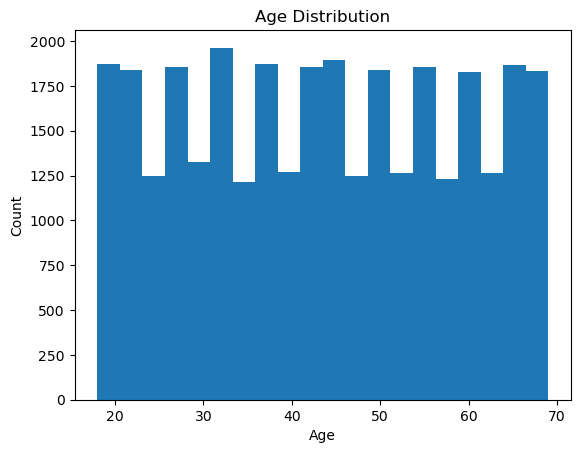

In [17]:
plt.figure()
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Credit Score Distribution

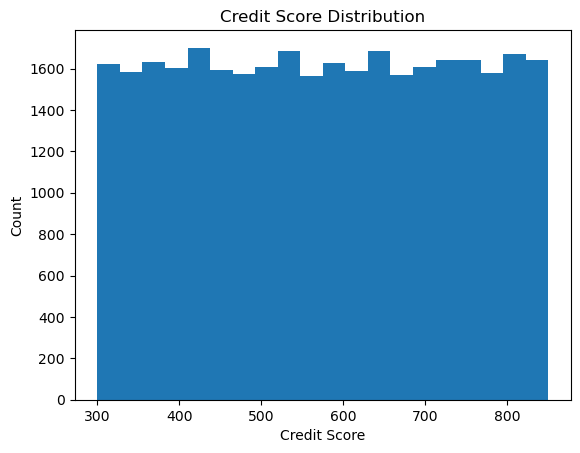

In [18]:
plt.figure()
plt.hist(df['credit_score'], bins=20)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

### Debt-to-Income Ratio

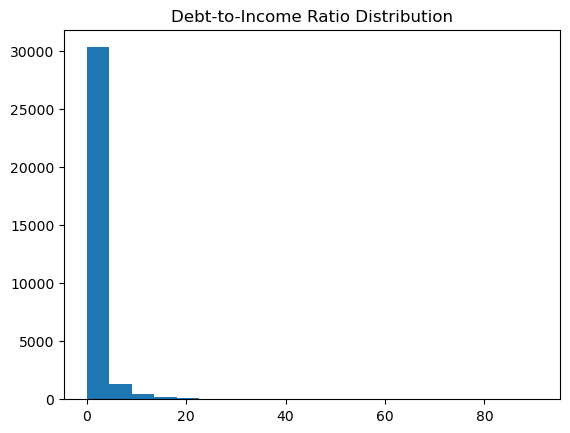

In [19]:
plt.figure()
plt.hist(df['debt_to_income_ratio'], bins=20)
plt.title("Debt-to-Income Ratio Distribution")
plt.show()

### Income vs Expenses

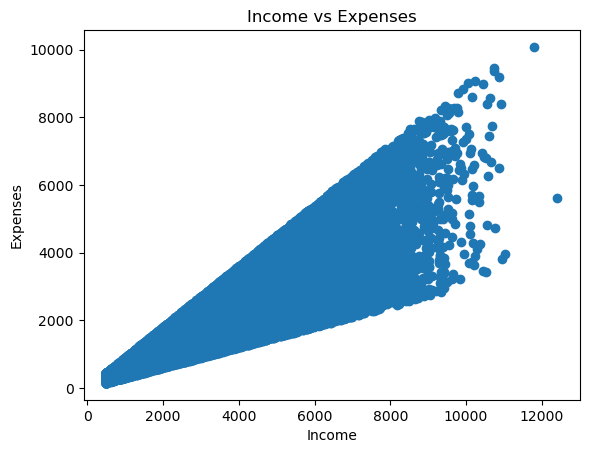

In [20]:
plt.figure()
plt.scatter(df['monthly_income_usd'], df['monthly_expenses_usd'])
plt.title("Income vs Expenses")
plt.xlabel("Income")
plt.ylabel("Expenses")
plt.show()

### Risk vs Credit Score

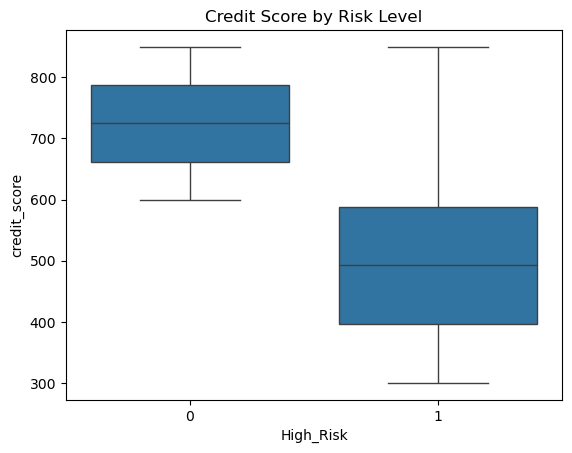

In [21]:
plt.figure()
sns.boxplot(x='High_Risk', y='credit_score', data=df)
plt.title("Credit Score by Risk Level")
plt.show()

### Risk vs Debt Ratio

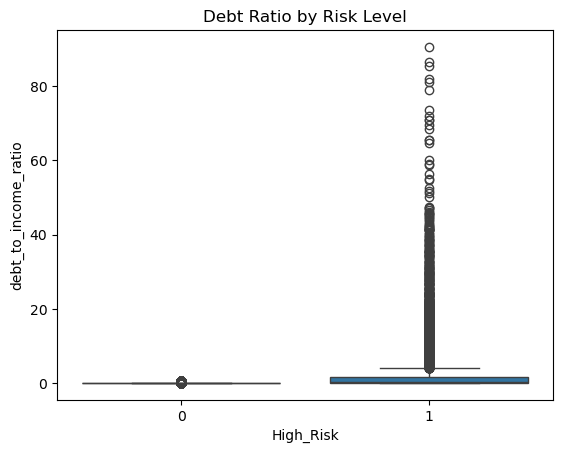

In [22]:
plt.figure()
sns.boxplot(x='High_Risk', y='debt_to_income_ratio', data=df)
plt.title("Debt Ratio by Risk Level")
plt.show()

### Correlation Heatmap

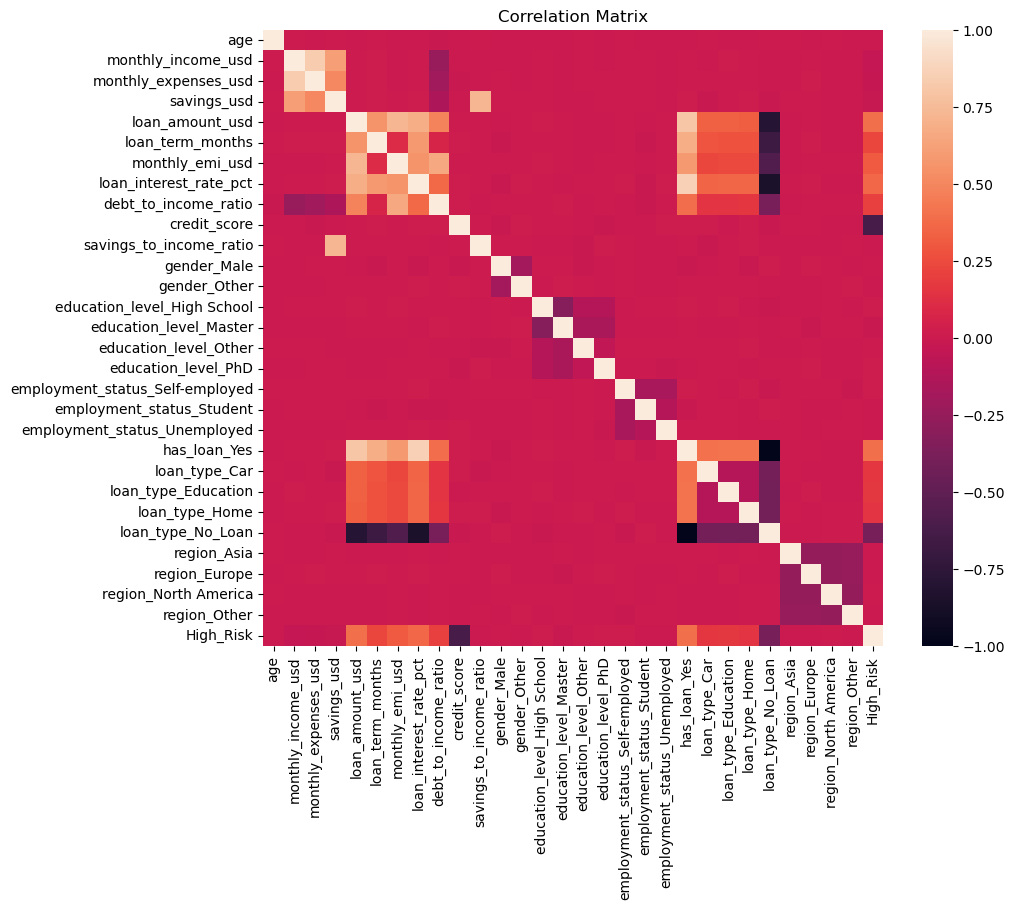

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Matrix")
plt.show()

### Feature Engineering Insight

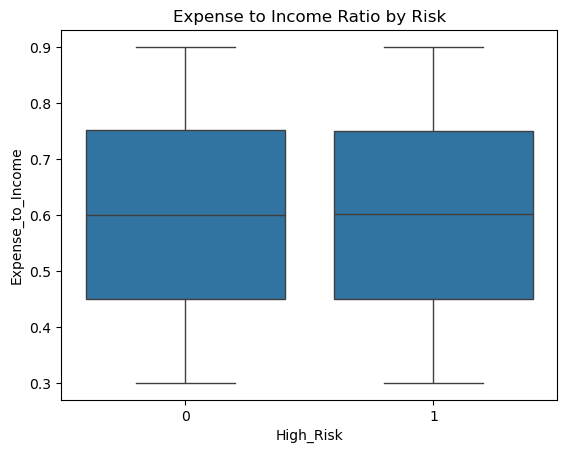

In [24]:
df['Expense_to_Income'] = df['monthly_expenses_usd'] / df['monthly_income_usd']

plt.figure()
sns.boxplot(x='High_Risk', y='Expense_to_Income', data=df)
plt.title("Expense to Income Ratio by Risk")
plt.show()

# Define Features & Target

In [25]:
X = df.drop('High_Risk', axis=1)
y = df['High_Risk']

# Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Models

## Logistic Regression

In [28]:
lr = LogisticRegression(max_iter=1000)

In [29]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
lr_pred = lr.predict(X_test)

In [31]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9762528912875867


In [32]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1993
           1       0.98      0.98      0.98      4492

    accuracy                           0.98      6485
   macro avg       0.97      0.97      0.97      6485
weighted avg       0.98      0.98      0.98      6485



## Random Forest

In [33]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
rf_pred = rf.predict(X_test)

In [36]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


In [37]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1993
           1       1.00      1.00      1.00      4492

    accuracy                           1.00      6485
   macro avg       1.00      1.00      1.00      6485
weighted avg       1.00      1.00      1.00      6485



# Feature Importance

In [38]:
importances = rf.feature_importances_
feature_names = df.drop('High_Risk', axis=1).columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                            Feature  Importance
9                      credit_score    0.680515
8              debt_to_income_ratio    0.086409
6                   monthly_emi_usd    0.056239
4                   loan_amount_usd    0.045025
7            loan_interest_rate_pct    0.031458
20                     has_loan_Yes    0.020382
24                loan_type_No_Loan    0.018679
5                  loan_term_months    0.016420
1                monthly_income_usd    0.007091
2              monthly_expenses_usd    0.006159
3                       savings_usd    0.005604
29                Expense_to_Income    0.004923
10          savings_to_income_ratio    0.004838
0                               age    0.003930
22              loan_type_Education    0.002635
21                    loan_type_Car    0.002432
23                   loan_type_Home    0.001355
11                      gender_Male    0.000646
17  employment_status_Self-employed    0.000542
14           education_level_Master    0

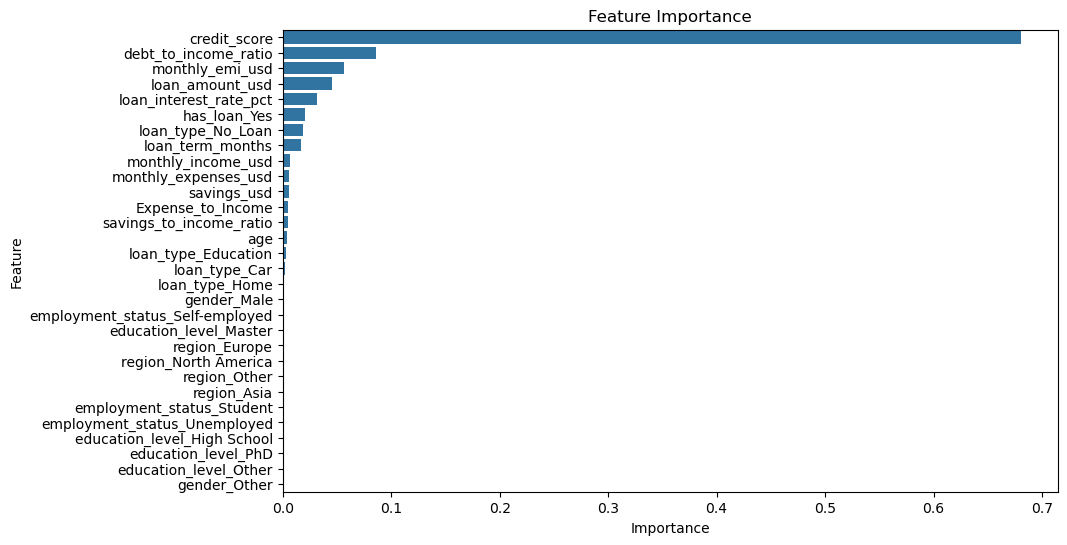

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance")
plt.show()

In [40]:
df.columns

Index(['age', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd',
       'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd',
       'loan_interest_rate_pct', 'debt_to_income_ratio', 'credit_score',
       'savings_to_income_ratio', 'gender_Male', 'gender_Other',
       'education_level_High School', 'education_level_Master',
       'education_level_Other', 'education_level_PhD',
       'employment_status_Self-employed', 'employment_status_Student',
       'employment_status_Unemployed', 'has_loan_Yes', 'loan_type_Car',
       'loan_type_Education', 'loan_type_Home', 'loan_type_No_Loan',
       'region_Asia', 'region_Europe', 'region_North America', 'region_Other',
       'High_Risk', 'Expense_to_Income'],
      dtype='object')

In [41]:
#import pickle

# After training your model
#with open("financial_risk_model.pkl", "wb") as file:
#    pickle.dump(rf, file)

In [42]:
#import sklearn
#print("Sklearn working")


Sklearn working


In [53]:
# Save
import joblib
model_filename = "ML-Financial Risk Prediction.joblib"

joblib.dump(rf, model_filename)
print(f"\nModel saved successfully as: {model_filename}")

# Optional: also save feature names for later use
joblib.dump(feature_importance_df, "feature_columns.joblib")
print("Feature column names saved as: feature_columns.joblib")


Model saved successfully as: ML-Financial Risk Prediction.joblib
Feature column names saved as: feature_columns.joblib


In [54]:
rf = joblib.load('ML-Financial Risk Prediction.joblib')   # or whatever your filename is

print("Model:", type(rf).__name__)
print("Has coef_ ?           ", hasattr(rf, 'coef_'))
print("Has feature_importances_ ?", hasattr(rf, 'feature_importances_'))
print("Classes:", getattr(rf, 'classes_', 'N/A'))
print("Number of features (if known):", 
      getattr(rf, 'n_features_in_', 'unknown'))

if hasattr(rf, 'feature_names_in_'):
    print("Feature names:", rf.feature_names_in_)

Model: RandomForestClassifier
Has coef_ ?            False
Has feature_importances_ ? True
Classes: [0 1]
Number of features (if known): 30
